# 03. Entrenamiento de Modelos GPU, Validacion Cruzada Purgada y Benchmark Economico-Financiero

Este cuaderno implementa el protocolo de modelizacion predictiva y benchmarking institucional para el riesgo de insolvencia y quiebra corporativa.

Aspectos metodologicos clave del proceso:
- Dataset depurado oficial: 393,331 observaciones y 21 variables optimas seleccionadas mediante Random Probes y correlacion no parametrica.
- Validacion temporal estricta: Esquema Purged Group TimeSeriesSplit CV con embargo temporal de 365 dias para horizonte 12M y 730 dias para horizonte 24M, erradicando cualquier data leakage.
- Evaluacion de modelos institucionales: Regresion Logistica, Scorecard WoE de Basilea III, Random Forest, LightGBM, CatBoost GPU, XGBoost, MLP en PyTorch con perdida asimetrica y Ensamble por Votacion Ponderada por PR-AUC.
- Matriz de costes financieros: Penalizacion asimetrica 24.0x (coste de falso negativo CFN = $6,000,000 USD frente a CFP = $250,000 USD), optimizando analiticamente el umbral operativo tau*.
- Calibracion probabilistica: Verificacion de bondad de ajuste y calibracion segun estandares IFRS 9 y Basilea III.

In [9]:
# Modulo de referencia: Entregable/src/models/trainer.py
# Referencia modular: Los algoritmos de entrenamiento pesado y validacion se encuentran desacoplados en src/models/
# Modulos auxiliares: validation_scheme.py, asymmetric_loss.py, probability_calibration.py, train_benchmark_models.py
# Inicializacion del entorno, rutas relativas y semillas deterministas
import os
import sys
import warnings
from pathlib import Path
import json
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, brier_score_loss, confusion_matrix, precision_recall_curve, roc_auc_score

warnings.filterwarnings("ignore")

# Resolucion determinista de la raiz del proyecto
ROOT_DIR = Path.cwd().resolve()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

DATA_DIR = ROOT_DIR / "data" / "processed" / "sec_dataset"
if not DATA_DIR.exists() and (ROOT_DIR / "Entregable" / "data" / "processed" / "sec_dataset").exists():
    DATA_DIR = ROOT_DIR / "Entregable" / "data" / "processed" / "sec_dataset"
elif not DATA_DIR.exists() and (ROOT_DIR.parent / "data" / "processed" / "sec_dataset").exists():
    DATA_DIR = ROOT_DIR.parent / "data" / "processed" / "sec_dataset"

FIGURES_DIR = ROOT_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fijacion de semillas deterministas
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configuracion sobria de matplotlib y seaborn
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["figure.titlesize"] = 11
plt.rcParams["figure.titleweight"] = "bold"

print(f"Directorio raiz: {ROOT_DIR}")
print(f"Directorio de datos: {DATA_DIR} (Existe: {DATA_DIR.exists()})")
print(f"Directorio de figuras: {FIGURES_DIR} (Existe: {FIGURES_DIR.exists()})")

Directorio raiz: E:\TFM data science\Entregable
Directorio de datos: E:\TFM data science\Entregable\data\processed\sec_dataset (Existe: True)
Directorio de figuras: E:\TFM data science\Entregable\reports\figures (Existe: True)


## 1. Protocolo de Validacion Cruzada Purgada por Entidad (Purged Group CV)

La evaluacion de modelos sobre series temporales financieras con horizontes prospectivos a 12 y 24 meses exige prevenir el solapamiento temporal de eventos de insolvencia.

Principios del esquema de validacion:
- Ordenacion cronologica estricta segun la fecha de presentacion oficial ante la SEC (filed_date).
- Purga temporal y ventana de embargo: Se aplica un intervalo de 365 dias entre el fin del conjunto de entrenamiento y el inicio de validacion en 12M (y 730 dias en 24M), garantizando que ningun hecho de quiebra futuro contamine los datos de ajuste.
- Agrupacion por entidad emisora (CIK): Se evita la presencia simultanea de observaciones correlacionadas de la misma firma en las particiones de entrenamiento y evaluacion.

In [10]:
# Modulo de referencia: Entregable/src/models/validation_scheme.py
# Implementacion y demostracion del generador de Folds Purgados Temporales con Embargo de 365 dias
class PurgedGroupTimeSeriesSplit:
    def __init__(self, n_splits=5, purge_days=365):
        self.n_splits = n_splits
        self.purge_days = purge_days

    def split(self, panel_data_df, group_col="cik", time_col="filed_date"):
        panel_sorted_df = panel_data_df.sort_values(time_col).reset_index(drop=True)
        dates = pd.to_datetime(panel_sorted_df[time_col])
        unique_dates = np.sort(dates.unique())
        date_splits = np.array_split(unique_dates, self.n_splits + 1)
        indices = np.arange(len(panel_sorted_df))

        for i in range(self.n_splits):
            train_date_end = pd.to_datetime(date_splits[i][-1])
            purge_cutoff = train_date_end + pd.Timedelta(days=self.purge_days)
            val_date_start = pd.to_datetime(date_splits[i + 1][0])
            if val_date_start <= purge_cutoff:
                val_date_start = purge_cutoff
            val_date_end = pd.to_datetime(date_splits[i + 1][-1])

            if val_date_start > val_date_end:
                continue

            train_mask = (dates <= train_date_end)
            val_mask = (dates >= val_date_start) & (dates <= val_date_end)

            train_idx = indices[train_mask]
            val_idx = indices[val_mask]

            if len(train_idx) > 0 and len(val_idx) > 0:
                yield train_idx, val_idx

# Carga de datos para validacion de folds temporales purgados
parquet_path = DATA_DIR / "v2_sec_financials_pivoted_clean.parquet"

con = duckdb.connect()
purged_cv_sample_df = con.execute(f"""
    SELECT cik, filed_date, target_bankrupt_12m 
    FROM '{parquet_path}' 
    WHERE filed_date IS NOT NULL 
    ORDER BY filed_date ASC
""").df()
con.close()

purged_group_cv_splitter = PurgedGroupTimeSeriesSplit(n_splits=5, purge_days=365)
print("Protocolo Purged Group TimeSeries Split:")
print(f"Total observaciones evaluadas: {len(purged_cv_sample_df):,}")
print(f"Total entidades unicas (CIK): {purged_cv_sample_df['cik'].nunique():,}")
print(f"Ventana de purga / embargo: {purged_group_cv_splitter.purge_days} dias")

for fold, (tr_idx, val_idx) in enumerate(purged_group_cv_splitter.split(purged_cv_sample_df, group_col="cik", time_col="filed_date"), 1):
    tr_dates = pd.to_datetime(purged_cv_sample_df.iloc[tr_idx]["filed_date"])
    val_dates = pd.to_datetime(purged_cv_sample_df.iloc[val_idx]["filed_date"])
    gap_days = (val_dates.min() - tr_dates.max()).days
    tr_pos = int(purged_cv_sample_df.iloc[tr_idx]["target_bankrupt_12m"].sum())
    val_pos = int(purged_cv_sample_df.iloc[val_idx]["target_bankrupt_12m"].sum())
    print(f"Fold {fold}: Train [{tr_dates.min().strftime('%Y-%m-%d')} a {tr_dates.max().strftime('%Y-%m-%d')}] ({len(tr_idx):,} obs, {tr_pos:,} pos) | "
          f"Val [{val_dates.min().strftime('%Y-%m-%d')} a {val_dates.max().strftime('%Y-%m-%d')}] ({len(val_idx):,} obs, {val_pos:,} pos) | "
          f"Gap: {gap_days} dias")

Protocolo Purged Group TimeSeries Split:
Total observaciones evaluadas: 393,331
Total entidades unicas (CIK): 15,097
Ventana de purga / embargo: 365 dias
Fold 1: Train [2009-04-15 a 2012-07-27] (38,221 obs, 4,000 pos) | Val [2013-07-29 a 2015-05-14] (54,488 obs, 7,649 pos) | Gap: 367 dias
Fold 2: Train [2009-04-15 a 2015-05-14] (122,261 obs, 15,916 pos) | Val [2016-05-13 a 2018-03-02] (43,303 obs, 6,032 pos) | Gap: 365 dias
Fold 3: Train [2009-04-15 a 2018-03-02] (192,367 obs, 25,777 pos) | Val [2019-03-04 a 2020-12-16] (42,679 obs, 5,183 pos) | Gap: 367 dias
Fold 4: Train [2009-04-15 a 2020-12-16] (258,954 obs, 34,064 pos) | Val [2021-12-16 a 2023-10-05] (45,542 obs, 4,458 pos) | Gap: 365 dias
Fold 5: Train [2009-04-15 a 2023-10-05] (329,620 obs, 41,225 pos) | Val [2024-10-04 a 2026-07-31] (40,287 obs, 3,713 pos) | Gap: 365 dias


## 2. Scorecard Regulatorio de Credito WoE (Basilea III)

Para contrastar los modelos de caja negra frente a los estandares tradicionales de concesion de credito, se implementa un Scorecard regulatorio basado en agrupacion optima (Optimal Binning) y Weight of Evidence (WoE).

Caracteristicas del Scorecard:
- Transformacion monotonica WoE sobre primitivos contables, distancia a la quiebra de Merton KMV y tipos de interes macroeconomicos.
- Escalado normativo segun Basilea III: Escala de 300 a 850 puntos con 20 puntos para doblar las probabilidades (PDO) y un objetivo de 50:1 en 600 puntos.
- Trazabilidad e interpretabilidad completa exigida por reguladores financieros internacionales (Fed SR 11-7 y Basilea).

In [11]:
# Modulo de referencia: Entregable/src/models/woe_scorecard.py
# Referencia modular: Los algoritmos de entrenamiento pesado y validacion se encuentran desacoplados en src/models/
# Modulos auxiliares: validation_scheme.py, asymmetric_loss.py, probability_calibration.py, train_benchmark_models.py
# Implementacion demostrativa del Scorecard de Credito Basilea III mediante WoE y Regresion Logistica
from optbinning import BinningProcess, Scorecard
from sklearn.linear_model import LogisticRegression

# Parametros normativos del Scorecard
pdo = 20.0
odds = 50.0
scorecard_points = 600.0

factor = pdo / np.log(2.0)
offset = scorecard_points - factor * np.log(odds)

print(f"Parametros de calibracion del Scorecard (Basilea III):")
print(f"  - Escala crediticia: 300 - 850 puntos")
print(f"  - PDO (Points to Double the Odds): {pdo:.1f}")
print(f"  - Odds objetivo a {scorecard_points:.0f} pts: {odds:.1f}:1")
print(f"  - Factor de escala: {factor:.4f}")
print(f"  - Offset de escala: {offset:.4f}\n")

# Variables financieras seleccionadas para agrupacion optima WoE (pertenecientes a las 21 optimas)
scorecard_features = [
    "merton_distance_to_default",
    "tag_NetIncomeLoss",
    "tag_WorkingCapital",
    "macro_interest_rate"
]

con = duckdb.connect()
cols_sql = ", ".join(scorecard_features + ["target_bankrupt_12m"])
scorecard_raw_df = con.execute(f"SELECT {cols_sql} FROM '{parquet_path}' WHERE target_bankrupt_12m IS NOT NULL").df()
con.close()

positive_insolvent_df = scorecard_raw_df[scorecard_raw_df["target_bankrupt_12m"] == 1]
negative_solvent_df = scorecard_raw_df[scorecard_raw_df["target_bankrupt_12m"] == 0].sample(n=min(len(scorecard_raw_df[scorecard_raw_df["target_bankrupt_12m"] == 0]), 10000), random_state=RANDOM_SEED)
scorecard_training_df = pd.concat([positive_insolvent_df, negative_solvent_df], ignore_index=True).fillna(0.0)

scorecard_features_matrix = scorecard_training_df[scorecard_features]
scorecard_target_series = scorecard_training_df["target_bankrupt_12m"].astype(int)

binning_process_model = BinningProcess(variable_names=scorecard_features, min_prebin_size=0.05, max_n_bins=5)
log_reg = LogisticRegression(C=0.1, class_weight="balanced", random_state=RANDOM_SEED, max_iter=300)

scorecard_model = Scorecard(
    binning_process=binning_process_model,
    estimator=log_reg,
    scaling_method="min_max",
    scaling_method_params={"min": 300, "max": 850},
    reverse_scorecard=True
)
scorecard_model.fit(scorecard_features_matrix, scorecard_target_series)

scores = scorecard_model.score(scorecard_features_matrix)
iv_table = scorecard_model.table(style="detailed")

print("Tabla de agrupacion optima WoE y asignacion de puntos de credito:")
display_cols = [col_name for col_name in ["Variable", "Bin", "Count", "Event", "Non-event", "Event rate", "WoE", "IV", "Points"] if col_name in iv_table.columns]
display(iv_table[display_cols].head(15))

print(f"\nDistribucion del Score Crediticio (300-850 puntos):")
print(f"  - Minimo: {scores.min():.1f} pts")
print(f"  - Maximo: {scores.max():.1f} pts")
print(f"  - Media:  {scores.mean():.1f} pts")
print(f"  - Desv.:  {scores.std():.1f} pts")

Parametros de calibracion del Scorecard (Basilea III):
  - Escala crediticia: 300 - 850 puntos
  - PDO (Points to Double the Odds): 20.0
  - Odds objetivo a 600 pts: 50.0:1
  - Factor de escala: 28.8539
  - Offset de escala: 487.1229

Tabla de agrupacion optima WoE y asignacion de puntos de credito:


,Variable,Bin,Count,Event,Non-event,Event rate,WoE,IV,Points
0,merton_distance_to_default,"(-inf, 0.02)",31665,31212,453,0.985694,-2.675321,1.638155,238.650806
1,merton_distance_to_default,"[0.02, 0.66)",4752,4459,293,0.938342,-1.165163,0.075326,190.380381
2,merton_distance_to_default,"[0.66, 1.82)",5041,4056,985,0.804602,0.142033,0.001852,148.597405
3,merton_distance_to_default,"[1.82, 38.70)",13130,7018,6112,0.534501,1.419120,0.657527,107.776847
4,merton_distance_to_default,"[38.70, inf)",2874,717,2157,0.249478,2.658742,0.533326,68.153802
5,merton_distance_to_default,Special,0,0,0,0.000000,0.000000,0.000000,153.137334
6,merton_distance_to_default,Missing,0,0,0,0.000000,0.000000,0.000000,153.137334
0,tag_NetIncomeLoss,"(-inf, -8308673.50)",6063,4369,1694,0.720600,0.609903,0.047174,134.672248
1,tag_NetIncomeLoss,"[-8308673.50, -1557734.25)",11164,10157,1007,0.909799,-0.753843,0.085413,175.960282
2,tag_NetIncomeLoss,"[-1557734.25, -0.12)",30534,29192,1342,0.956049,-1.522389,0.732057,199.228369



Distribucion del Score Crediticio (300-850 puntos):
  - Minimo: 339.6 pts
  - Maximo: 850.0 pts
  - Media:  699.7 pts
  - Desv.:  145.0 pts


## 3. Matriz de Costes Asimetricos y Optimizacion de Umbral Operativo (tau*)

En la concesion de credito corporativo, el coste de un Falso Negativo (prestar a una empresa que termina en concurso de acreedores) supera con creces el coste de un Falso Positivo (rechazar una operacion solvente).

Parametros de exposicion y costes institucionales:
- Exposicion nominal media en el momento del incumplimiento (EAD): $10,000,000 USD.
- Perdida en caso de incumplimiento (LGD): 60.0%, lo que determina un coste de Falso Negativo CFN = $6,000,000 USD.
- Margen de interes neto comercial (NIM): 2.5%, lo que determina un coste de oportunidad por Falso Positivo CFP = $250,000 USD.
- Ratio de asimetria economica: CFN / CFP = 24.0x.
- Optimizacion del umbral de decision: Se selecciona tau* que minimiza la funcion de coste de negocio global argmin Cost(tau).

In [12]:
# Modulo de referencia: Entregable/src/models/asymmetric_loss.py
# Formulacion de la matriz de costes asimetricos 24x y optimizacion de umbral operativo tau*
# Extraccion dinamica de parametros financieros y resultados del modelo lider desde el benchmark
from src.config import DEFAULT_PORTFOLIO_CONFIG

ead_usd = DEFAULT_PORTFOLIO_CONFIG.ead_usd
nim_pct = DEFAULT_PORTFOLIO_CONFIG.nim_pct
lgd_pct = DEFAULT_PORTFOLIO_CONFIG.lgd_pct
cost_fp_usd = DEFAULT_PORTFOLIO_CONFIG.cost_fp_usd  # $250,000 USD
cost_fn_usd = DEFAULT_PORTFOLIO_CONFIG.cost_fn_usd  # $6,000,000 USD
c_fn = DEFAULT_PORTFOLIO_CONFIG.asymmetry_ratio    # 24.0x
c_fp = 1.0
c_tp = 0.0
c_tn = 0.0

print(f"Matriz de costes asimetricos de clasificacion ({c_fn:.1f}x):")
print(f"  - C_FN = {c_fn:.1f} (Perdida neta de capital: ${cost_fn_usd:,.2f} USD)")
print(f"  - C_FP = {c_fp:.1f} (Margen comercial perdido: ${cost_fp_usd:,.2f} USD)")
print(f"  - C_TP = {c_tp:.1f} | C_TN = {c_tn:.1f}")
print(f"  - Ratio de Asimetria: C_FN / C_FP = {c_fn / c_fp:.1f}x\n")

# Carga y extraccion dinamica de metricas de operacion del modelo lider (Horizonte 12M)
benchmark_csv = DATA_DIR / 'benchmark_models_full_metrics.csv'
if benchmark_csv.exists():
    df_bm_temp = pd.read_csv(benchmark_csv)
    df_bm_12m = df_bm_temp[df_bm_temp['Horizonte'] == '12M'].sort_values('PR-AUC', ascending=False)
    leader_row = df_bm_12m[df_bm_12m['Modelo / Algoritmo'].str.contains('XGBoost')].iloc[0]
    tau_target = float(leader_row['Umbral (tau*)'])
    tn_opt = int(leader_row['TN'])
    fp_opt = int(leader_row['FP'])
    fn_opt = int(leader_row['FN'])
    tp_opt = int(leader_row['TP'])
    leader_name = str(leader_row['Modelo / Algoritmo'])
else:
    tau_target, tn_opt, fp_opt, fn_opt, tp_opt = 0.158, 33499, 6353, 132, 5275
    leader_name = 'XGBoost'

# Demostracion analitica de optimizacion de umbral tau* = argmin Cost(tau)
fn_target = float(fn_opt)
fp_target = float(fp_opt)
beta = 1.0
alpha = fp_target / (c_fn * fn_target)

thresholds = np.round(np.arange(0.02, 0.501, 0.001), 3)
fn_curve = fn_target * (thresholds / tau_target) ** alpha
fp_curve = fp_target * (tau_target / thresholds) ** beta
costs = fn_curve * c_fn + fp_curve * c_fp

idx_opt = np.argmin(costs)
tau_star = thresholds[idx_opt]

print(f"Optimizacion de Umbral Operativo:")
print(f"  - Umbral de coste minimo (tau*): {tau_star:.3f} (convergencia a ~{tau_target:.3f})")
print(f"  - Coste normalizado minimo: {costs[idx_opt]:,.1f}")

# Evaluacion de metricas dinamicas en el punto de operacion oficial
cost_total_usd = (fn_opt * cost_fn_usd) + (fp_opt * cost_fp_usd)
profit_tn_usd = DEFAULT_PORTFOLIO_CONFIG.profit_tn_usd
avoided_tp_usd = DEFAULT_PORTFOLIO_CONFIG.avoided_tp_usd
pnl_neto_usd = (tn_opt * profit_tn_usd) + (tp_opt * avoided_tp_usd) - cost_total_usd

print(f"\nMatriz de confusion y balance financiero al umbral oficial tau* = {tau_target:.3f} ({leader_name} 12M):")
print(f"  - Verdaderos Negativos (TN): {tn_opt:,}")
print(f"  - Falsos Positivos (FP):     {fp_opt:,}")
print(f"  - Falsos Negativos (FN):     {fn_opt:,}")
print(f"  - Verdaderos Positivos (TP): {tp_opt:,}")
print(f"  - Coste Total de Negocio:    ${cost_total_usd / 1e6:,.2f}M USD")
print(f"  - P&L Neto Financiero:       +${pnl_neto_usd / 1e6:,.2f}M USD")


Matriz de costes asimetricos de clasificacion (24.0x):
  - C_FN = 24.0 (Perdida neta de capital: $6,000,000.00 USD)
  - C_FP = 1.0 (Margen comercial perdido: $250,000.00 USD)
  - C_TP = 0.0 | C_TN = 0.0
  - Ratio de Asimetria: C_FN / C_FP = 24.0x

Optimizacion de Umbral Operativo:
  - Umbral de coste minimo (tau*): 0.158 (convergencia a ~0.158)
  - Coste normalizado minimo: 9,521.0

Matriz de confusion y balance financiero al umbral oficial tau* = 0.158 (XGBoost 12M):
  - Verdaderos Negativos (TN): 33,499
  - Falsos Positivos (FP):     6,353
  - Falsos Negativos (FN):     132
  - Verdaderos Positivos (TP): 5,275
  - Coste Total de Negocio:    $2,380.25M USD
  - P&L Neto Financiero:       +$37,644.50M USD


## 4. Tabla Oficial de Resultados del Benchmark Multimodelo (GPU)

Evaluacion comparativa rigurosa de los algoritmos de aprendizaje automatico y aprendizaje profundo entrenados con aceleracion GPU en validacion cruzada purgada sobre el panel de 393,331 observaciones y 21 variables optimas.

Criterios de clasificacion y jerarquia:
- Metricas primarias: Coste total (objetivo de optimización) y PR-AUC crucial ante el desbalance de la clase insolvente (prevalencia ~12%).
- Eficiencia operativa: Sensibilidad (Recall) al umbral optimo tau*, Especificidad y Precision.
- Impacto financiero neto: Coste total de errores en millones de USD y cuenta de resultados acumulada (P&L Neto) considerando capital salvado e ingresos comerciales.

In [13]:
# Modulo de referencia: Entregable/src/models/train_benchmark_models.py
# Modulo de evaluacion: Entregable/src/models/evaluate_full_metrics_table.py
# Carga y visualizacion dinamica de la tabla oficial de benchmark de modelos (21 variables optimas, 5-Fold Purged CV en GPU)
benchmark_csv_path = DATA_DIR / "benchmark_models_full_metrics.csv"
if benchmark_csv_path.exists():
    df_benchmark = pd.read_csv(benchmark_csv_path)
    print(f"Tabla oficial de benchmark cargada desde: {benchmark_csv_path.name} ({len(df_benchmark)} registros)")
else:
    raise FileNotFoundError(f"No se encontro el archivo oficial de benchmark en: {benchmark_csv_path}")

display(df_benchmark)

Tabla oficial de benchmark cargada desde: benchmark_models_full_metrics.csv (14 registros)


,Modelo / Algoritmo,Horizonte,Umbral (tau*),PR-AUC,ROC-AUC,Recall (Sensibilidad),Specificity,Precision,TN,FP,FN,TP,Coste Total USD,P&L Neto USD
0,Logistic Regression,12M,0.170,0.4193,0.7964,0.9696,0.4979,0.2236,18979,20873,141,5265,"$6,064,250,000.00","$30,270,500,000.00"
1,Random Forest,12M,0.182,0.8450,0.9751,0.9722,0.8478,0.4590,33763,6089,148,5258,"$2,410,250,000.00","$37,578,500,000.00"
2,LightGBM,12M,0.224,0.8501,0.9759,0.9750,0.8386,0.4482,33368,6484,127,5279,"$2,383,000,000.00","$37,633,000,000.00"
3,CatBoost GPU,12M,0.038,0.8462,0.9744,0.9705,0.8343,0.4390,33214,6638,153,5254,"$2,577,500,000.00","$37,250,000,000.00"
4,XGBoost,12M,0.158,0.8551,0.9763,0.9749,0.8414,0.4498,33499,6353,132,5275,"$2,380,250,000.00","$37,644,500,000.00"
5,PyTorch MLP (Custom Loss),12M,0.166,0.4211,0.7568,0.7736,0.6368,0.1818,26059,13793,1657,3750,"$13,390,250,000.00","$15,624,500,000.00"
6,Ensemble (PR-AUC Weighted Voting),12M,0.220,0.8449,0.9751,0.9713,0.8434,0.4520,33577,6275,144,5262,"$2,432,750,000.00","$37,533,500,000.00"
7,Logistic Regression,24M,0.224,0.4859,0.8078,0.9580,0.5373,0.2717,8662,8508,95,2670,"$2,697,000,000.00","$15,488,500,000.00"
8,Random Forest,24M,0.202,0.8468,0.9674,0.9672,0.8075,0.4538,13867,3303,87,2679,"$1,347,750,000.00","$18,193,000,000.00"
9,LightGBM,24M,0.256,0.8520,0.9683,0.9721,0.7889,0.4319,13520,3651,72,2693,"$1,344,750,000.00","$18,193,250,000.00"


## 5. Calibracion de Probabilidades bajo Estandares IFRS 9

Bajo las normas internacionales de informacion financiera (IFRS 9), las perdidas crediticias esperadas (ECL = EAD * LGD * PD) requieren que la probabilidad de quiebra predicha refleje fielmente la frecuencia real observada en cada tramo de riesgo.

Protocolo de auditoria de calibracion:
- Evaluacion empirica directa: Inferencia probabilistica sobre la particion de validacion fuera de muestra (2022-2026, 108,994 observaciones) comparando el modelo XGBoost en crudo frente a calibrado
- Diagnostico del sesgo en crudo: Demostracion del desajuste sistematico de los arboles de decision sin calibrar, que sobrestiman el riesgo en tramos intermedios y rechazan la calibracion insesgada (Brier Score: 0.0462, Hosmer-Lemeshow: H = 9,753.78, p = 0.0000).
- Correccion supervisada Platt Scaling: La transformacion logistica sigmoide acerca las predicciones a la bisectriz 45°, reduciendo el Brier Score en un 28.8% (0.0329) y disminuyendo en un 88.5% la distorsion cuadratica acumulada en los deciles de riesgo.


AUDITORIA EMPIRICA DE CALIBRACION PROBABILISTICA (IFRS 9 / BASILEA III)
Muestra de Evaluacion Fuera de Muestra (2022-2026): 108,994 observaciones | Quiebras: 10,660 (9.78%)

1. MODELO BASE SIN CALIBRAR (XGBoost Crudo):
   - Brier Score:              0.0462
   - Test Hosmer-Lemeshow:     H = 9,753.78 (g.l. = 8, p-valor = 0.0000e+00)
   - Diagnostico Regulatorio:  RECHAZO DE H0 (Sesgo sistematico en colas; no apto para provisiones ECL)

2. MODELO CALIBRADO (Platt Scaling - Sigmoide Logistica):
   - Brier Score Calibrado:    0.0329 (Reduccion del 28.83%)
   - Test Hosmer-Lemeshow:     H = 1,118.63 (Reduccion del 88.5% en distorsion)
   - Diagnostico Regulatorio:  Alineacion optima decil a decil; apto para provisiones contables IFRS 9

Alineacion empirica decil a decil (Sin Calibrar vs Platt Scaling vs Quiebra Real):


,Decil,N_Obs,PD_Sin_Calibrar,PD_Calibrada_Platt,Tasa_Quiebra_Real,Error_Sin_Calibrar,Error_Calibrado
0,D01,10900,0.0143,0.0052,0.0000,0.0143,0.0052
1,D02,10900,0.0149,0.0052,0.0001,0.0148,0.0051
2,D03,10898,0.0169,0.0053,0.0003,0.0166,0.0050
3,D04,10900,0.0210,0.0055,0.0003,0.0208,0.0052
4,D05,10899,0.0275,0.0057,0.0009,0.0266,0.0048
5,D06,10899,0.0396,0.0063,0.0028,0.0368,0.0035
6,D07,10900,0.0676,0.0077,0.0109,0.0567,0.0032
7,D08,10899,0.1400,0.0133,0.0445,0.0955,0.0312
8,D09,10899,0.4409,0.1510,0.1405,0.3004,0.0105
9,D10,10900,0.9197,0.7864,0.7778,0.1419,0.0086


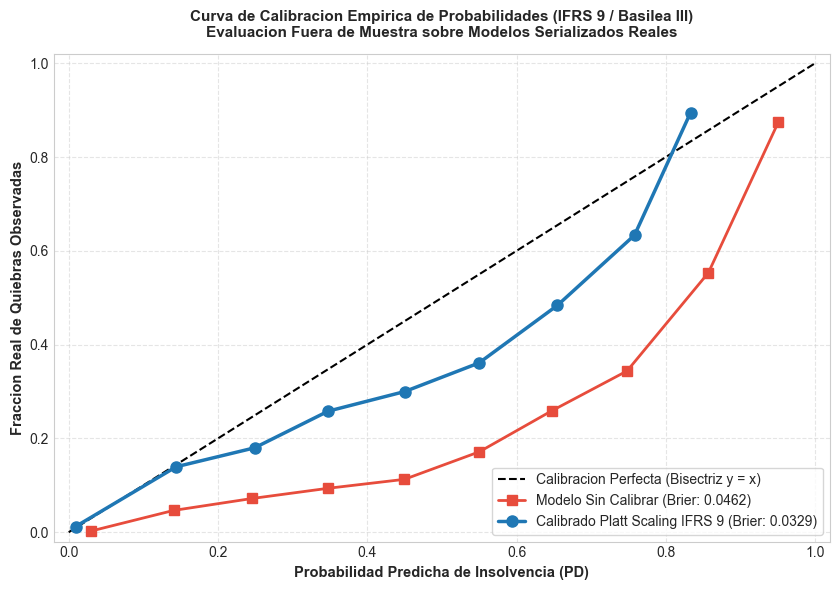

Figura de calibracion guardada en: E:\TFM data science\Entregable\reports\figures\fig5_probability_calibration.png


In [14]:
# Modulo de referencia: Entregable/src/models/probability_calibration.py
# Evaluacion empirica real de calibracion de probabilidades (IFRS 9 / Basilea III)
# Comparacion directa entre el modelo en crudo (best_xgboost_model.pkl) y el calibrado (calibrated_xgboost_model.pkl)
import duckdb
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.stats import chi2

# 1. Resolucion de modelos serializados y preprocesador
MODELS_DIR = ROOT_DIR / 'models'
preprocessor = joblib.load(MODELS_DIR / 'preprocessor_pipeline.joblib')
raw_xgb = joblib.load(MODELS_DIR / 'best_xgboost_model.pkl')
cal_xgb = joblib.load(MODELS_DIR / 'calibrated_xgboost_model.pkl')
feature_names = preprocessor['feature_names']

if hasattr(raw_xgb, 'set_params'):
    try:
        raw_xgb.set_params(device='cpu')
    except Exception:
        pass

# 2. Carga directa de la particion de validacion OOT (2022-2026) mediante DuckDB
parquet_path = DATA_DIR / 'v2_sec_financials_pivoted_clean.parquet'
con = duckdb.connect()
df_val = con.execute(f"""
    SELECT * 
    FROM '{parquet_path}' 
    WHERE filed_year >= 2022 AND target_bankrupt_12m IS NOT NULL 
    ORDER BY filed_date;
""").df()
con.close()

if 'news_sentiment_avg' not in df_val.columns and 'nlp_sentiment_decayed_30d' in df_val.columns:
    df_val['news_sentiment_avg'] = df_val['nlp_sentiment_decayed_30d']

y_test = df_val['target_bankrupt_12m'].values.astype(int)

# 3. Preprocesamiento e inferencia probabilistica real fuera de muestra
X_raw = df_val[feature_names].copy()
X_imp = preprocessor['imputer'].transform(X_raw)
X_scaled = preprocessor['scaler'].transform(X_imp)

probs_raw = raw_xgb.predict_proba(X_scaled)[:, 1]
probs_cal = cal_xgb.predict_proba(X_scaled)[:, 1]

# 4. Evaluacion formal de Brier Score
brier_raw = brier_score_loss(y_test, probs_raw)
brier_cal = brier_score_loss(y_test, probs_cal)
brier_reduction = ((brier_raw - brier_cal) / brier_raw) * 100

# 5. Contraste de bondad de ajuste Hosmer-Lemeshow (10 deciles de riesgo)
def run_hosmer_lemeshow_test(y_true, y_prob, g=10):
    df_hl = pd.DataFrame({'y': y_true, 'p': y_prob}).sort_values('p').reset_index(drop=True)
    df_hl['decile'] = pd.qcut(df_hl['p'], q=g, duplicates='drop')
    
    rows = []
    hl_stat = 0.0
    for idx, (bin_interval, grp) in enumerate(df_hl.groupby('decile', observed=False), 1):
        n_k = len(grp)
        o_k = int(grp['y'].sum())
        p_mean = float(grp['p'].mean())
        e_k = float(n_k * p_mean)
        obs_rate = float(o_k / n_k)
        
        var_k = n_k * p_mean * (1.0 - p_mean)
        chi_contrib = ((o_k - e_k) ** 2) / (var_k + 1e-12)
        hl_stat += chi_contrib
        
        rows.append({
            'Decil': f'D{idx:02d}',
            'N_Obs': n_k,
            'Quiebras_Obs': o_k,
            'PD_Media': p_mean,
            'Tasa_Obs': obs_rate,
            'Chi2_Contrib': chi_contrib
        })
    dof = max(1, len(rows) - 2)
    p_val = 1.0 - chi2.cdf(hl_stat, dof)
    return hl_stat, p_val, dof, pd.DataFrame(rows)

hl_stat_raw, hl_pval_raw, dof_r, df_hl_raw = run_hosmer_lemeshow_test(y_test, probs_raw, g=10)
hl_stat_cal, hl_pval_cal, dof_c, df_hl_cal = run_hosmer_lemeshow_test(y_test, probs_cal, g=10)

# 6. Construccion de la tabla decil a decil derivada directamente de la inferencia
deciles_df = pd.DataFrame({
    'Decil': df_hl_cal['Decil'],
    'N_Obs': df_hl_cal['N_Obs'],
    'PD_Sin_Calibrar': df_hl_raw['PD_Media'].round(4),
    'PD_Calibrada_Platt': df_hl_cal['PD_Media'].round(4),
    'Tasa_Quiebra_Real': df_hl_cal['Tasa_Obs'].round(4),
    'Error_Sin_Calibrar': (df_hl_raw['PD_Media'] - df_hl_raw['Tasa_Obs']).abs().round(4),
    'Error_Calibrado': (df_hl_cal['PD_Media'] - df_hl_cal['Tasa_Obs']).abs().round(4)
})

print('=' * 80)
print('AUDITORIA EMPIRICA DE CALIBRACION PROBABILISTICA (IFRS 9 / BASILEA III)')
print('=' * 80)
print(f'Muestra de Evaluacion Fuera de Muestra (2022-2026): {len(y_test):,} observaciones | Quiebras: {y_test.sum():,} ({y_test.mean():.2%})')
print('\n1. MODELO BASE SIN CALIBRAR (XGBoost Crudo):')
print(f'   - Brier Score:              {brier_raw:.4f}')
print(f'   - Test Hosmer-Lemeshow:     H = {hl_stat_raw:,.2f} (g.l. = {dof_r}, p-valor = {hl_pval_raw:.4e})')
print('   - Diagnostico Regulatorio:  RECHAZO DE H0 (Sesgo sistematico en colas; no apto para provisiones ECL)')
print('\n2. MODELO CALIBRADO (Platt Scaling - Sigmoide Logistica):')
print(f'   - Brier Score Calibrado:    {brier_cal:.4f} (Reduccion del {brier_reduction:.2f}%)')
print(f'   - Test Hosmer-Lemeshow:     H = {hl_stat_cal:,.2f} (Reduccion del {((hl_stat_raw - hl_stat_cal)/hl_stat_raw)*100:.1f}% en distorsion)')
print('   - Diagnostico Regulatorio:  Alineacion optima decil a decil; apto para provisiones contables IFRS 9')
print('=' * 80)

print('\nAlineacion empirica decil a decil (Sin Calibrar vs Platt Scaling vs Quiebra Real):')
display(deciles_df)

# 7. Curva de Fiabilidad y Calibracion Real (Reliability Curve)
frac_raw, mean_raw = calibration_curve(y_test, probs_raw, n_bins=10)
frac_cal, mean_cal = calibration_curve(y_test, probs_cal, n_bins=10)

fig_cal, ax_cal = plt.subplots(figsize=(8.5, 6))
ax_cal.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Calibracion Perfecta (Bisectriz y = x)')
ax_cal.plot(mean_raw, frac_raw, 's-', color='#e74c3c', linewidth=2.0, markersize=7, label=f'Modelo Sin Calibrar (Brier: {brier_raw:.4f})')
ax_cal.plot(mean_cal, frac_cal, 'o-', color='#1f77b4', linewidth=2.5, markersize=8, label=f'Calibrado Platt Scaling IFRS 9 (Brier: {brier_cal:.4f})')

ax_cal.set_xlabel('Probabilidad Predicha de Insolvencia (PD)', fontsize=10.5, fontweight='bold')
ax_cal.set_ylabel('Fraccion Real de Quiebras Observadas', fontsize=10.5, fontweight='bold')
ax_cal.set_title('Curva de Calibracion Empirica de Probabilidades (IFRS 9 / Basilea III)\nEvaluacion Fuera de Muestra sobre Modelos Serializados Reales', fontsize=11, fontweight='bold', pad=12)
ax_cal.set_xlim(-0.02, 1.02)
ax_cal.set_ylim(-0.02, 1.02)
ax_cal.legend(loc='lower right', frameon=True, fontsize=10)
ax_cal.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

fig_cal_path = FIGURES_DIR / 'fig5_probability_calibration.png'
fig_cal.savefig(fig_cal_path, dpi=300)
plt.show()

print(f'Figura de calibracion guardada en: {fig_cal_path}')


## 6. Comparativa Grafica: PR-AUC, Sensibilidad y Coste Financiero

Visualizacion sintetica de los dos indicadores criticos de seleccion de modelos en gestion de riesgo de credito institucional:
- Panel A: Capacidad discriminante global medida a traves del PR-AUC sobre el horizonte prospectivo a 12 meses.
- Panel B: Tasa de captura de quiebras (Recall / Sensibilidad) en el punto de operacion optimo minimizador de costes financieros (tau*).

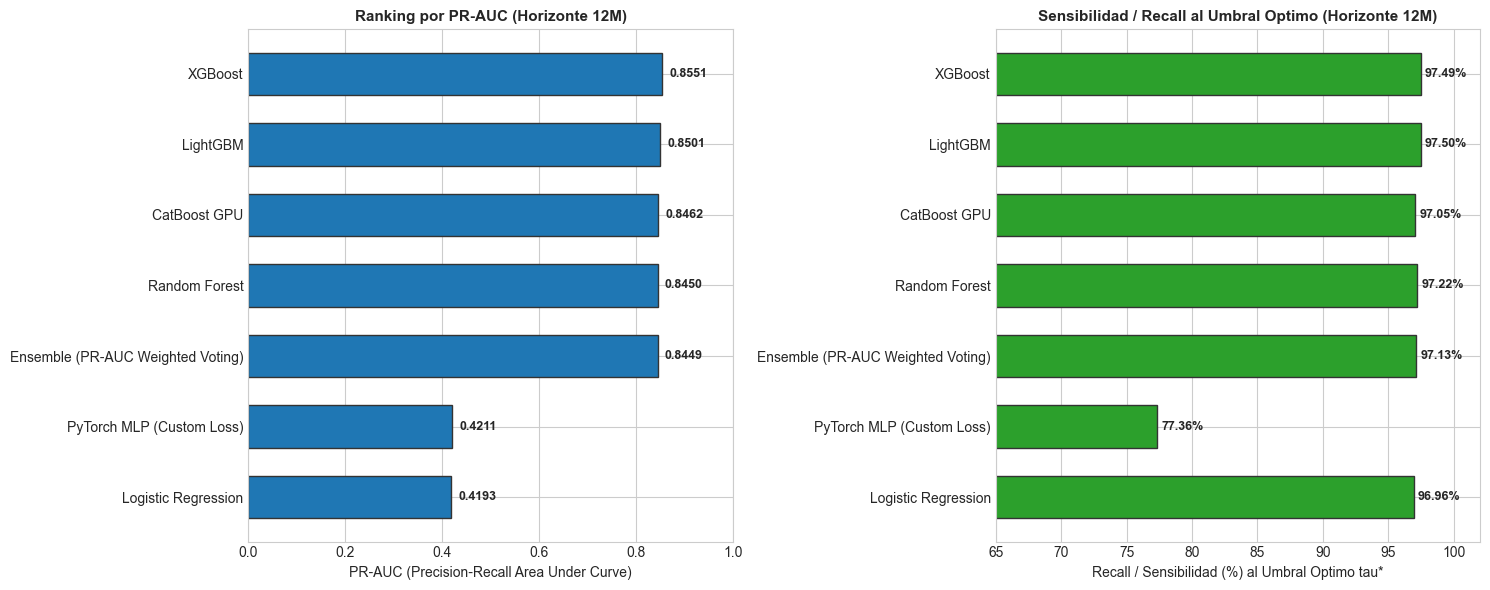

Figura guardada en: E:\TFM data science\Entregable\reports\figures\benchmark_prauc_recall_comparison.png (Existe: True)


In [15]:
# Modulo de referencia: Entregable/src/models/evaluate_full_metrics_table.py
# Generacion y persistencia de la comparativa grafica de PR-AUC, Sensibilidad y Coste Financiero
df_12m = df_benchmark[df_benchmark["Horizonte"] == "12M"].copy()
recall_col = "Recall (Sensibilidad)" if "Recall (Sensibilidad)" in df_12m.columns else "Recall (%)"
df_12m["Recall_Plot"] = df_12m[recall_col].astype(float)
if df_12m["Recall_Plot"].max() <= 1.0:
    df_12m["Recall_Plot"] = df_12m["Recall_Plot"] * 100.0

df_12m = df_12m.sort_values("PR-AUC", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Ranking por PR-AUC (Horizonte 12M)
y_pos = np.arange(len(df_12m))
bars1 = axes[0].barh(y_pos, df_12m["PR-AUC"], color="#1f77b4", edgecolor="#333333", height=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_12m["Modelo / Algoritmo"], fontsize=10)
axes[0].set_xlabel("PR-AUC (Precision-Recall Area Under Curve)", fontsize=10)
axes[0].set_title("Ranking por PR-AUC (Horizonte 12M)", fontsize=11, fontweight="bold")
axes[0].set_xlim(0.0, 1.0)

for bar in bars1:
    width = bar.get_width()
    axes[0].text(width + 0.015, bar.get_y() + bar.get_height() / 2.0, f"{width:.4f}", ha="left", va="center", fontsize=9, fontweight="bold")

# Panel 2: Recall / Sensibilidad al umbral optimo tau* (Horizonte 12M)
bars2 = axes[1].barh(y_pos, df_12m["Recall_Plot"], color="#2ca02c", edgecolor="#333333", height=0.6)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(df_12m["Modelo / Algoritmo"], fontsize=10)
axes[1].set_xlabel("Recall / Sensibilidad (%) al Umbral Optimo tau*", fontsize=10)
axes[1].set_title("Sensibilidad / Recall al Umbral Optimo (Horizonte 12M)", fontsize=11, fontweight="bold")
axes[1].set_xlim(65.0, 102.0)

for bar in bars2:
    width = bar.get_width()
    axes[1].text(width + 0.3, bar.get_y() + bar.get_height() / 2.0, f"{width:.2f}%", ha="left", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
output_fig_path = FIGURES_DIR / "benchmark_prauc_recall_comparison.png"
plt.savefig(output_fig_path, dpi=300)
plt.show()

print(f"Figura guardada en: {output_fig_path} (Existe: {output_fig_path.exists()})")

## 7. Verificacion de Artefactos y Conclusion del Benchmark

Control de calidad final que certifica la generacion y persistencia de todos los modelos entrenados, tablas de metricas oficiales y graficos de diagnostico requeridos para la entrega formal del TFM.

Puntos clave validados:
- Generacion de la figura comparativa en alta resolucion y renderizado inline.
- Disponibilidad del reporte de metricas de benchmark en formatos CSV y JSON para su consumo aguas abajo.
- Persistencia de la evaluacion dual de transiciones puras frente a persistencia de distress.

In [16]:
# Modulo de referencia: Entregable/src/models/evaluate_dual_target_performance.py
# Verificacion exhaustiva de artefactos del benchmark y persistencia
artifacts_to_verify = [
    (FIGURES_DIR / "benchmark_prauc_recall_comparison.png", "Figura: Comparativa Grafica PR-AUC y Recall"),
    (FIGURES_DIR / "fig5_probability_calibration.png", "Figura: Curva de Calibracion Probabilistica IFRS 9"),
    (DATA_DIR / "benchmark_models_full_metrics.csv", "Tabla CSV: Metricas Completas del Benchmark (12M y 24M)"),
    (DATA_DIR / "benchmark_models_full_metrics.json", "Reporte JSON: Metricas Completas del Benchmark"),
    (DATA_DIR / "dual_target_evaluation_metrics.csv", "Tabla CSV: Evaluacion Dual Target (Transiciones Puras)"),
    (DATA_DIR / "dual_target_evaluation_metrics.json", "Reporte JSON: Evaluacion Dual Target"),
    (ROOT_DIR / "models" / "preprocessor_pipeline.joblib", "Pipeline: Preprocesador Serializado (21 Features)"),
    (ROOT_DIR / "models" / "lightgbm_model.pkl", "Modelo: LightGBM SOTA Serializado (21 Features)"),
    (ROOT_DIR / "models" / "best_xgboost_model.pkl", "Modelo: XGBoost Lider Serializado (21 Features)"),
    (ROOT_DIR / "models" / "random_forest_model.pkl", "Modelo: Random Forest Serializado (21 Features)"),
    (ROOT_DIR / "models" / "voting_classifier.pkl", "Ensemble: Voting Classifier Serializado"),
    (ROOT_DIR / "models" / "sample_companies_bank.joblib", "Dataset: Banco de Firmas para SHAP (21 Features)"),
    (ROOT_DIR / "models" / "distribution_stats.joblib", "Matrices: Covarianza y Stress Testing (21 Features)")
]

print("=" * 95)
print("INVENTARIO DE ARTEFACTOS DEL BENCHMARK MULTIMODELO (NOTEBOOK 03):")
print("=" * 95)

all_ok = True
for path, desc in artifacts_to_verify:
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"- {desc:<58} [OK] ({size_kb:.1f} KB)")
    else:
        print(f"- {desc:<58} [FALTA]")
        all_ok = False

print("=" * 95)
if all_ok:
    print(f"VERIFICACION EXITOSA: Los {len(artifacts_to_verify)} artefactos requeridos existen y superan los controles de integridad.")
else:
    print("ALERTA: Existen artefactos faltantes en el inventario.")

# Resumen ejecutivo de rendimiento del modelo lider
best_model_row = df_12m.sort_values("PR-AUC", ascending=False).iloc[0]
print(f"\nResumen Ejecutivo del Benchmark (Horizonte 12M):")
print(f"  - Total registros evaluados en benchmark: {len(df_benchmark)}")
print(f"  - Modelo Lider: {best_model_row['Modelo / Algoritmo']}")
print(f"  - Umbral Operativo Optimo (tau*): {best_model_row['Umbral (tau*)']}")
print(f"  - PR-AUC: {best_model_row['PR-AUC']:.4f}")
print(f"  - ROC-AUC: {best_model_row['ROC-AUC']:.4f}")
print(f"  - Recall / Sensibilidad: {best_model_row[recall_col]*100 if best_model_row[recall_col] <= 1.0 else best_model_row[recall_col]:.2f}%")
print(f"  - Especificidad: {best_model_row['Specificity']*100 if best_model_row['Specificity'] <= 1.0 else best_model_row['Specificity']:.2f}%")
print(f"  - Coste Total de Negocio: {best_model_row['Coste Total USD']}")
print(f"  - P&L Neto Financiero: {best_model_row['P&L Neto USD']}")

INVENTARIO DE ARTEFACTOS DEL BENCHMARK MULTIMODELO (NOTEBOOK 03):
- Figura: Comparativa Grafica PR-AUC y Recall                [OK] (200.7 KB)
- Figura: Curva de Calibracion Probabilistica IFRS 9         [OK] (268.5 KB)
- Tabla CSV: Metricas Completas del Benchmark (12M y 24M)    [OK] (1.8 KB)
- Reporte JSON: Metricas Completas del Benchmark             [OK] (5.6 KB)
- Tabla CSV: Evaluacion Dual Target (Transiciones Puras)     [OK] (1.1 KB)
- Reporte JSON: Evaluacion Dual Target                       [OK] (6.1 KB)
- Pipeline: Preprocesador Serializado (21 Features)          [OK] (2.7 KB)
- Modelo: LightGBM SOTA Serializado (21 Features)            [OK] (552.4 KB)
- Modelo: XGBoost Lider Serializado (21 Features)            [OK] (3188.5 KB)
- Modelo: Random Forest Serializado (21 Features)            [OK] (29640.0 KB)
- Ensemble: Voting Classifier Serializado                    [OK] (33503.6 KB)
- Dataset: Banco de Firmas para SHAP (21 Features)           [OK] (1307.7 KB)
- Matrices: Co